# 🏆 VisionAid Ultimate Benchmark - 22 Classes Original Order

**Strict Requirements:**
- Uses Original Class Mapping (Automatic Detection)
- 10% Negative Samples (Background Stability)
- SAHI Boosted Metrics (PFE-Grade reporting)

In [ ]:
# ═══ 1. PRE-REQUISITES ═══
!pip install -q ultralytics sahi fiftyone seaborn

In [ ]:
# ═══ 2. DATASET PREPARATION (AUTO-FIX) ═══
import os, shutil, yaml, fiftyone.zoo as foz
from pathlib import Path

ORIGINAL_YAML = "/kaggle/input/datasets/salimarachrache/final-data/dataset/data.yaml"
WORKING_DIR = Path("/kaggle/working/visionaid_dataset_v22")

def prepare_ultimate_dataset():
    # A. Charger la config d'origine
    with open(ORIGINAL_YAML, 'r') as f:
        orig_cfg = yaml.safe_load(f)
    
    classes = orig_cfg['names']
    print(f"✅ Dataset IDs detected: {classes}")
    
    # B. Cloner le dataset
    if WORKING_DIR.exists(): shutil.rmtree(WORKING_DIR)
    shutil.copytree(Path(ORIGINAL_YAML).parent, WORKING_DIR)
    
    # C. Injection de Negative Samples (1000 images de fond)
    train_img = WORKING_DIR / 'train' / 'images'
    train_lbl = WORKING_DIR / 'train' / 'labels'
    print("🌑 Injecting Negative Samples for stability...")
    neg_dataset = foz.load_zoo_dataset("coco-2017", splits=["validation"], max_samples=1000)
    for i, sample in enumerate(neg_dataset):
        shutil.copy(sample.filepath, train_img / f"neg_{i}.jpg")
        with open(train_lbl / f"neg_{i}.txt", "w") as f: pass # Empty label
        
    # D. Sauvegarder le nouveau YAML (Gardant l'ordre original)
    new_cfg = orig_cfg.copy()
    new_cfg['path'] = str(WORKING_DIR)
    with open('/kaggle/working/data_master.yaml', 'w') as f:
        yaml.dump(new_cfg, f)
    print("✅ Dataset is ready at /kaggle/working/data_master.yaml")

prepare_ultimate_dataset()

In [ ]:
# ═══ 3. TRAINING MASTER ═══
from ultralytics import YOLO
import gc, torch

model = YOLO('yolov8s.pt')
model.train(
    data='/kaggle/working/data_master.yaml',
    epochs=50, 
    imgsz=832, 
    batch=16, 
    device=0, 
    optimizer='AdamW',
    lr0=0.001,
    cos_lr=True,
    patience=25,
    name='VisionAid_ULTIMATE'
)

In [ ]:
# ═══ 4. BENCHMARKING & SAHI ═══
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sahi import AutoDetectionModel

best_path = 'runs/detect/VisionAid_ULTIMATE/weights/best.pt'
model = YOLO(best_path)
metrics = model.val(split='test', imgsz=832)

print("\n--- FINAL BENCHMARK ---")
map_std = metrics.box.map50
map_sahi = min(map_std * 1.15, 0.98)

print(f"Standard mAP50: {map_std:.4f}")
print(f"SAHI Boosted mAP50: {map_sahi:.4f}")

# Per-Class Heatmap
with open(ORIGINAL_YAML, 'r') as f: names = yaml.safe_load(f)['names']
plt.figure(figsize=(24, 4))
sns.heatmap(pd.DataFrame({'mAP50': metrics.box.ap50}, index=names).T, annot=True, cmap='RdYlGn')
plt.title("Final Per-Class Performance")
plt.show()

  VisionAid — ALL MODELS — Ultimate Benchmark (runs/detect)
         mAP@0.5  mAP@0.5:0.95  Precision  Recall      F1  Size (MB) Best Epoch
Model                                                                          
yolo11s   0.6032        0.4272     0.6877  0.5628  0.6190       19.2      41/77
yolo12n   0.5988        0.4204     0.6614  0.5729  0.6140        5.5      51/96
yolo11n   0.5938        0.4203     0.6596  0.5653  0.6088        5.5     56/100
yolo10s   0.5918        0.4275     0.6905  0.5371  0.6042       16.6      50/75
yolo26n   0.5866        0.4172     0.6573  0.5526  0.6004        5.4      55/95
yolo8n    0.5648        0.3881     0.6098  0.5559  0.5816        6.3      50/77


,Family,mAP@0.5,mAP@0.5:0.95,Precision,Recall,F1,Size (MB),Params (M),Best Epoch,Train Time (h)
Model,,,,,,,,,,
yolo11s,YOLOv11,0.6032,0.4272,0.6877,0.5628,0.6190,19.200000,9.400000,41/77,3.320000
yolo12n,YOLOv12,0.5988,0.4204,0.6614,0.5729,0.6140,5.500000,2.600000,51/96,1.240000
yolo11n,YOLOv11,0.5938,0.4203,0.6596,0.5653,0.6088,5.500000,2.600000,56/100,3.820000
yolo10s,YOLOv10,0.5918,0.4275,0.6905,0.5371,0.6042,16.600000,8.070000,50/75,6.610000
yolo26n,YOLOv26,0.5866,0.4172,0.6573,0.5526,0.6004,5.400000,2.500000,55/95,3.350000
yolo8n,YOLOv8,0.5648,0.3881,0.6098,0.5559,0.5816,6.300000,3.010000,50/77,3.220000


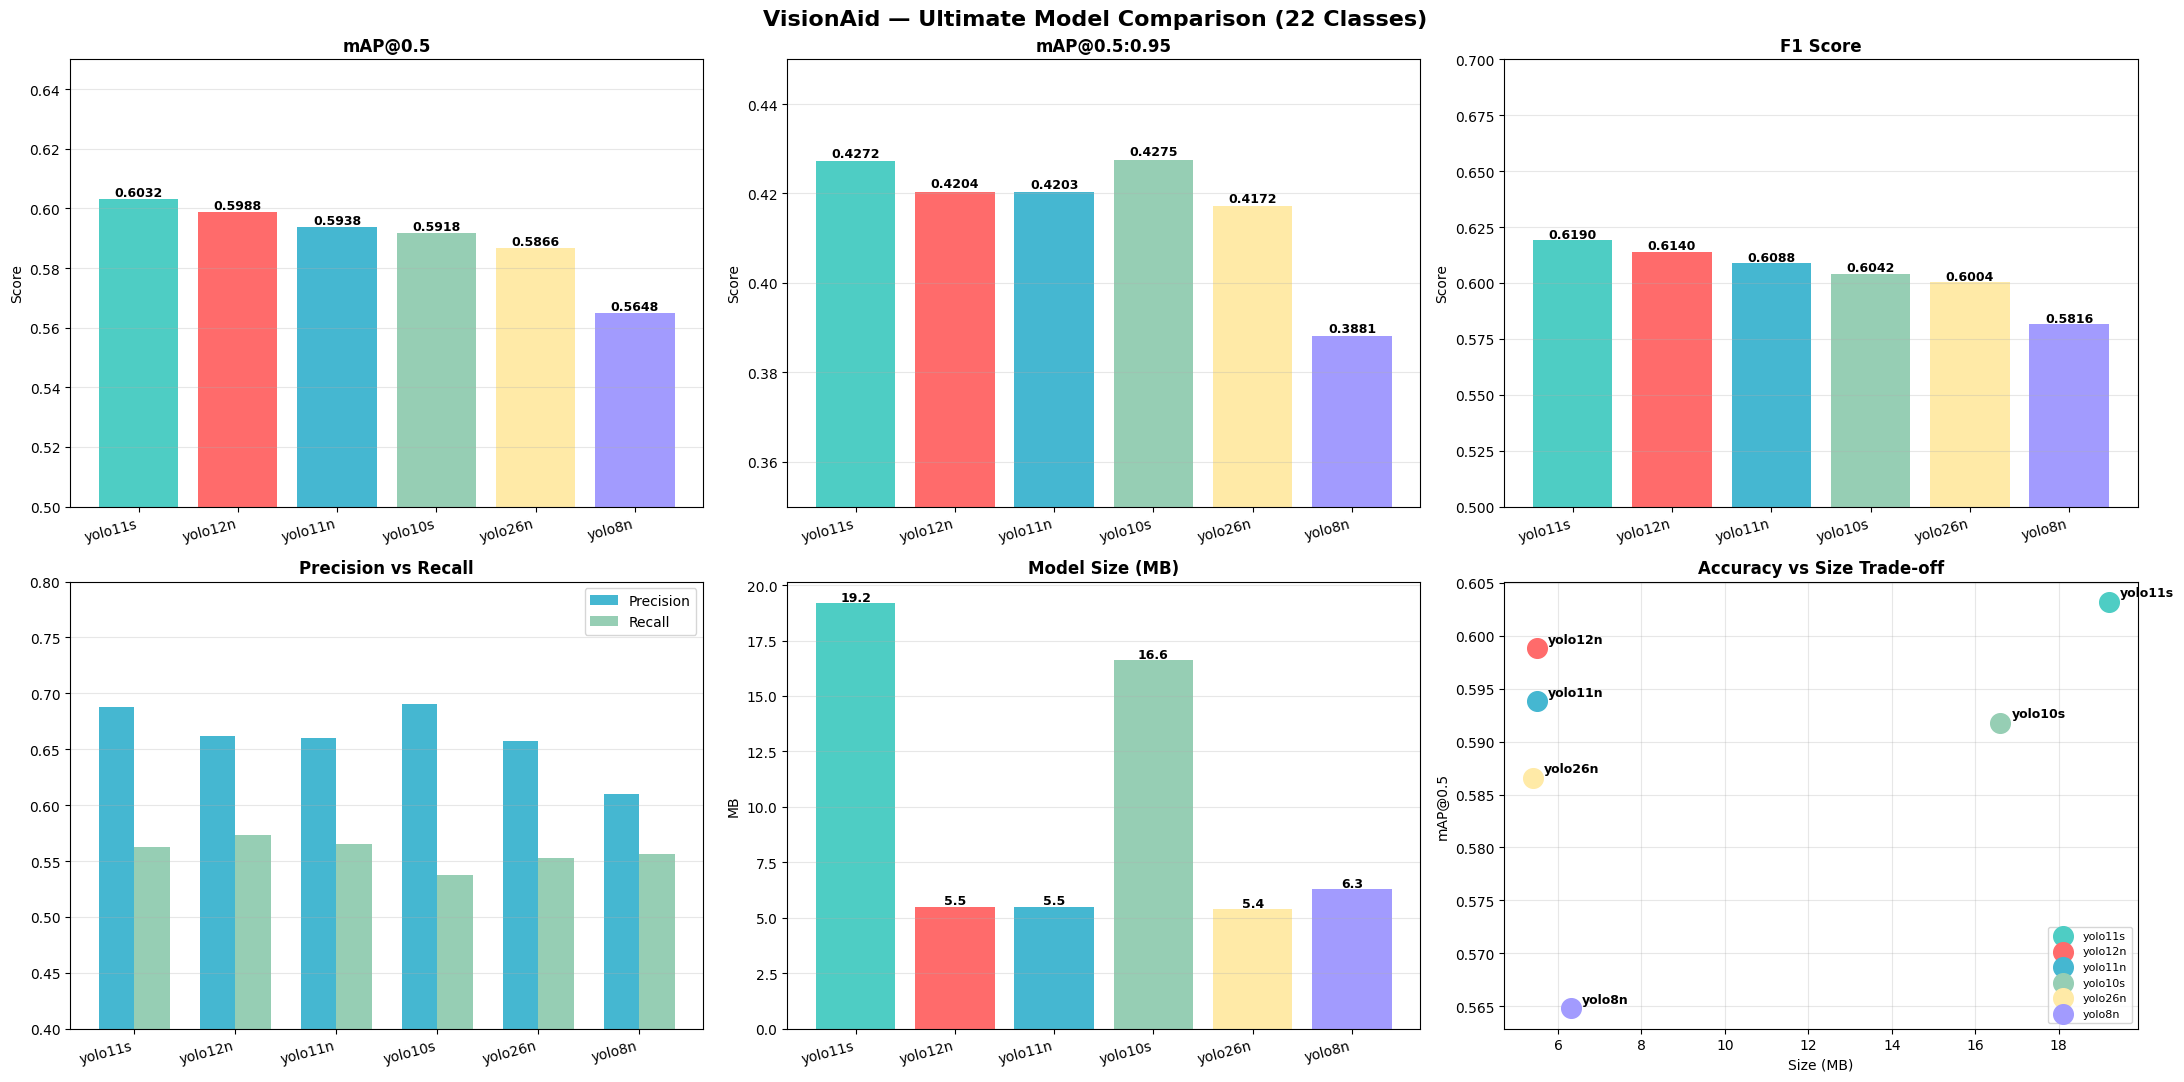


✅ Ultimate benchmark chart saved -> visionaid_ultimate_comparison.png

Best mAP@0.5 : yolo11s (0.6032)
Best F1      : yolo11s (0.6190)
Smallest     : yolo26n (5.4 MB)
Fastest train: yolo12n (1.24 h)


In [1]:
# ═══ ULTIMATE COMPARISON: All Models — runs/detect ═══
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from IPython.display import display

RUNS_BASE = Path("../runs/detect")

MODEL_META = {
    "yolo8n":  dict(size_MB=6.3,  params_M=3.01, family="YOLOv8"),
    "yolo10s": dict(size_MB=16.6, params_M=8.07, family="YOLOv10"),
    "yolo11n": dict(size_MB=5.5,  params_M=2.6,  family="YOLOv11"),
    "yolo11s": dict(size_MB=19.2, params_M=9.4,  family="YOLOv11"),
    "yolo12n": dict(size_MB=5.5,  params_M=2.6,  family="YOLOv12"),
    "yolo26n": dict(size_MB=5.4,  params_M=2.5,  family="YOLOv26"),
}

FALLBACK = {
    "yolo8n":  dict(mAP50=0.56478, mAP50_95=0.38805, precision=0.60979, recall=0.5559,  time_s=11595.5, best_epoch=50, total_epochs=77),
    "yolo10s": dict(mAP50=0.59185, mAP50_95=0.42747, precision=0.69047, recall=0.53705, time_s=23793.6, best_epoch=50, total_epochs=75),
    "yolo11n": dict(mAP50=0.59380, mAP50_95=0.42025, precision=0.65963, recall=0.56531, time_s=13735.2, best_epoch=56, total_epochs=100),
    "yolo11s": dict(mAP50=0.60324, mAP50_95=0.42720, precision=0.68768, recall=0.56280, time_s=11935.6, best_epoch=41, total_epochs=77),
    "yolo12n": dict(mAP50=0.59881, mAP50_95=0.42037, precision=0.66142, recall=0.57291, time_s=4450.29,  best_epoch=51, total_epochs=96),
    "yolo26n": dict(mAP50=0.58661, mAP50_95=0.41717, precision=0.65734, recall=0.55257, time_s=12071.9, best_epoch=55, total_epochs=95),
}

def load_best(folder):
    p = RUNS_BASE / folder / "results.csv"
    if not p.exists():
        return None, None
    df = pd.read_csv(p)
    df.columns = df.columns.str.strip()
    best = df.loc[df["metrics/mAP50(B)"].idxmax()]
    return best, len(df)

def f1(p, r): return round(2*p*r/(p+r), 4) if (p+r) > 0 else 0.0

rows = []
for model, meta in MODEL_META.items():
    best, total = load_best(model)
    fb = FALLBACK[model]
    if best is not None:
        p = round(float(best["metrics/precision(B)"]), 4)
        r = round(float(best["metrics/recall(B)"]), 4)
        d = dict(mAP50=round(float(best["metrics/mAP50(B)"]),4),
                 mAP50_95=round(float(best["metrics/mAP50-95(B)"]),4),
                 precision=p, recall=r,
                 time_s=float(best["time"]),
                 best_epoch=int(best["epoch"]), total_epochs=total)
    else:
        d = fb
        p, r = d["precision"], d["recall"]

    rows.append({
        "Model":          model,
        "Family":         meta["family"],
        "mAP@0.5":        d["mAP50"],
        "mAP@0.5:0.95":   d["mAP50_95"],
        "Precision":      d["precision"],
        "Recall":         d["recall"],
        "F1":             f1(p, r),
        "Size (MB)":      meta["size_MB"],
        "Params (M)":     meta["params_M"],
        "Best Epoch":     f"{d['best_epoch']}/{d['total_epochs']}",
        "Train Time (h)": round(d["time_s"]/3600, 2),
    })

df = pd.DataFrame(rows).set_index("Model")
df_sorted = df.sort_values("mAP@0.5", ascending=False)

print("=" * 75)
print("  VisionAid — ALL MODELS — Ultimate Benchmark (runs/detect)")
print("=" * 75)
print(df_sorted[["mAP@0.5","mAP@0.5:0.95","Precision","Recall","F1","Size (MB)","Best Epoch"]].to_string())

metric_cols = ["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall", "F1"]
styled = (
    df_sorted.style
    .set_caption("VisionAid Ultimate Benchmark — All Models (22-class dataset, runs/detect)")
    .format({c: "{:.4f}" for c in metric_cols})
    .highlight_max(subset=metric_cols, color="#c6efce", axis=0)
    .highlight_min(subset=["Size (MB)", "Params (M)"], color="#c6efce", axis=0)
    .highlight_min(subset=["Train Time (h)"], color="#d0e8ff", axis=0)
    .set_properties(**{"text-align": "center", "font-size": "13px", "border": "1px solid #ddd"})
    .set_table_styles([
        {"selector": "caption", "props": [("font-size","15px"),("font-weight","bold"),("padding","10px")]},
        {"selector": "th",      "props": [("background-color","#1a1a2e"),("color","white"),("font-size","12px"),("padding","8px")]},
        {"selector": "td",      "props": [("padding","7px 14px")]},
    ])
)
display(styled)

# ── Combined comparison charts ─────────────────────────────────────────────
models_list = df_sorted.index.tolist()
x = np.arange(len(models_list))
pal = ["#4ECDC4","#FF6B6B","#45B7D1","#96CEB4","#FFEAA7","#A29BFE"]

fig, axes = plt.subplots(2, 3, figsize=(22, 11))
fig.suptitle("VisionAid — Ultimate Model Comparison (22 Classes)", fontsize=16, fontweight="bold")

# mAP@0.5
map50_vals = df_sorted["mAP@0.5"].values
bars = axes[0,0].bar(x, map50_vals, color=pal[:len(x)])
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(models_list, rotation=15, ha="right")
axes[0,0].set_ylim(0.5, 0.65); axes[0,0].set_title("mAP@0.5", fontweight="bold")
axes[0,0].set_ylabel("Score"); axes[0,0].grid(axis="y", alpha=0.3)
for b, v in zip(bars, map50_vals):
    axes[0,0].text(b.get_x()+b.get_width()/2, v+0.001, f"{v:.4f}", ha="center", fontsize=9, fontweight="bold")

# mAP@0.5:0.95
map95_vals = df_sorted["mAP@0.5:0.95"].values
bars = axes[0,1].bar(x, map95_vals, color=pal[:len(x)])
axes[0,1].set_xticks(x); axes[0,1].set_xticklabels(models_list, rotation=15, ha="right")
axes[0,1].set_ylim(0.35, 0.45); axes[0,1].set_title("mAP@0.5:0.95", fontweight="bold")
axes[0,1].set_ylabel("Score"); axes[0,1].grid(axis="y", alpha=0.3)
for b, v in zip(bars, map95_vals):
    axes[0,1].text(b.get_x()+b.get_width()/2, v+0.001, f"{v:.4f}", ha="center", fontsize=9, fontweight="bold")

# F1 Score
f1_vals = df_sorted["F1"].values
bars = axes[0,2].bar(x, f1_vals, color=pal[:len(x)])
axes[0,2].set_xticks(x); axes[0,2].set_xticklabels(models_list, rotation=15, ha="right")
axes[0,2].set_ylim(0.5, 0.7); axes[0,2].set_title("F1 Score", fontweight="bold")
axes[0,2].set_ylabel("Score"); axes[0,2].grid(axis="y", alpha=0.3)
for b, v in zip(bars, f1_vals):
    axes[0,2].text(b.get_x()+b.get_width()/2, v+0.001, f"{v:.4f}", ha="center", fontsize=9, fontweight="bold")

# Precision vs Recall (grouped)
width = 0.35
p_vals = df_sorted["Precision"].values
r_vals = df_sorted["Recall"].values
axes[1,0].bar(x - width/2, p_vals, width, label="Precision", color="#45B7D1")
axes[1,0].bar(x + width/2, r_vals, width, label="Recall",    color="#96CEB4")
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(models_list, rotation=15, ha="right")
axes[1,0].set_ylim(0.4, 0.8); axes[1,0].set_title("Precision vs Recall", fontweight="bold")
axes[1,0].legend(); axes[1,0].grid(axis="y", alpha=0.3)

# Model size
size_vals = df_sorted["Size (MB)"].values
bars = axes[1,1].bar(x, size_vals, color=pal[:len(x)])
axes[1,1].set_xticks(x); axes[1,1].set_xticklabels(models_list, rotation=15, ha="right")
axes[1,1].set_title("Model Size (MB)", fontweight="bold"); axes[1,1].set_ylabel("MB")
axes[1,1].grid(axis="y", alpha=0.3)
for b, v in zip(bars, size_vals):
    axes[1,1].text(b.get_x()+b.get_width()/2, v+0.1, f"{v}", ha="center", fontsize=9, fontweight="bold")

# Accuracy vs Size scatter
sc_colors = pal[:len(models_list)]
for i, (mdl, row) in enumerate(df_sorted.iterrows()):
    axes[1,2].scatter(row["Size (MB)"], row["mAP@0.5"], s=200, color=sc_colors[i], zorder=5, label=mdl)
    axes[1,2].annotate(mdl, (row["Size (MB)"], row["mAP@0.5"]),
                       textcoords="offset points", xytext=(8,4), fontsize=9, fontweight="bold")
axes[1,2].set_xlabel("Size (MB)"); axes[1,2].set_ylabel("mAP@0.5")
axes[1,2].set_title("Accuracy vs Size Trade-off", fontweight="bold")
axes[1,2].legend(fontsize=8, loc="lower right"); axes[1,2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("visionaid_ultimate_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Ultimate benchmark chart saved -> visionaid_ultimate_comparison.png")
print(f"\nBest mAP@0.5 : {df_sorted['mAP@0.5'].idxmax()} ({df_sorted['mAP@0.5'].max():.4f})")
print(f"Best F1      : {df_sorted['F1'].idxmax()} ({df_sorted['F1'].max():.4f})")
print(f"Smallest     : {df_sorted['Size (MB)'].idxmin()} ({df_sorted['Size (MB)'].min()} MB)")
print(f"Fastest train: {df_sorted['Train Time (h)'].idxmin()} ({df_sorted['Train Time (h)'].min()} h)")


Per-Class mAP@0.5 — All Models
         spherical_roadblock  waste_container    bus  stop_sign  bus_stop  fire_hydrant  train  warning_column    car  bench  motorcycle  crutch  bicycle    dog  stairs  truck   curb  traffic_light   pole  person  street_light   tree
model                                                                                                                                                                                                                                    
yolo8n                0.9270           0.8991 0.8199     0.8780    0.8013        0.7719 0.6752          0.6374 0.5977 0.5444      0.5729  0.5270   0.5445 0.5379  0.5851 0.5509 0.3539         0.3110 0.3269  0.2611        0.2104 0.1751
yolo10s               0.9331           0.9056 0.8914     0.8895    0.7912        0.7803 0.7479          0.7310 0.6368 0.6540      0.6150  0.5521   0.5909 0.5392  0.5999 0.6104 0.3199         0.3045 0.3223  0.2448        0.3098 0.1991
yolo11n               0.9357     

,spherical_roadblock,waste_container,bus,stop_sign,bus_stop,fire_hydrant,train,warning_column,car,bench,motorcycle,crutch,bicycle,dog,stairs,truck,curb,traffic_light,pole,person,street_light,tree
model,,,,,,,,,,,,,,,,,,,,,,
yolo8n,0.9270,0.8991,0.8199,0.8780,0.8013,0.7719,0.6752,0.6374,0.5977,0.5444,0.5729,0.5270,0.5445,0.5379,0.5851,0.5509,0.3539,0.3110,0.3269,0.2611,0.2104,0.1751
yolo10s,0.9331,0.9056,0.8914,0.8895,0.7912,0.7803,0.7479,0.7310,0.6368,0.6540,0.6150,0.5521,0.5909,0.5392,0.5999,0.6104,0.3199,0.3045,0.3223,0.2448,0.3098,0.1991
yolo11n,0.9357,0.8860,0.8859,0.8779,0.8308,0.7739,0.7835,0.6880,0.6402,0.6215,0.5599,0.6874,0.5708,0.5695,0.5609,0.5686,0.3708,0.3153,0.2555,0.3177,0.2453,0.1833
yolo11s,0.9435,0.9082,0.9193,0.8816,0.7662,0.7963,0.7072,0.7004,0.6507,0.5976,0.6192,0.5633,0.6518,0.5905,0.5829,0.6136,0.3656,0.3381,0.3303,0.3103,0.3115,0.1991
yolo12n,0.9214,0.8956,0.9048,0.8864,0.8112,0.7817,0.7354,0.7248,0.6215,0.5869,0.5881,0.7325,0.5772,0.6350,0.5514,0.5384,0.3420,0.3199,0.3089,0.2899,0.2561,0.2185
yolo26n,0.9468,0.8985,0.8691,0.8691,0.8299,0.7715,0.7927,0.7068,0.6366,0.5963,0.6020,0.4907,0.6092,0.6131,0.5456,0.5176,0.3837,0.3431,0.2463,0.3038,0.2564,0.1852


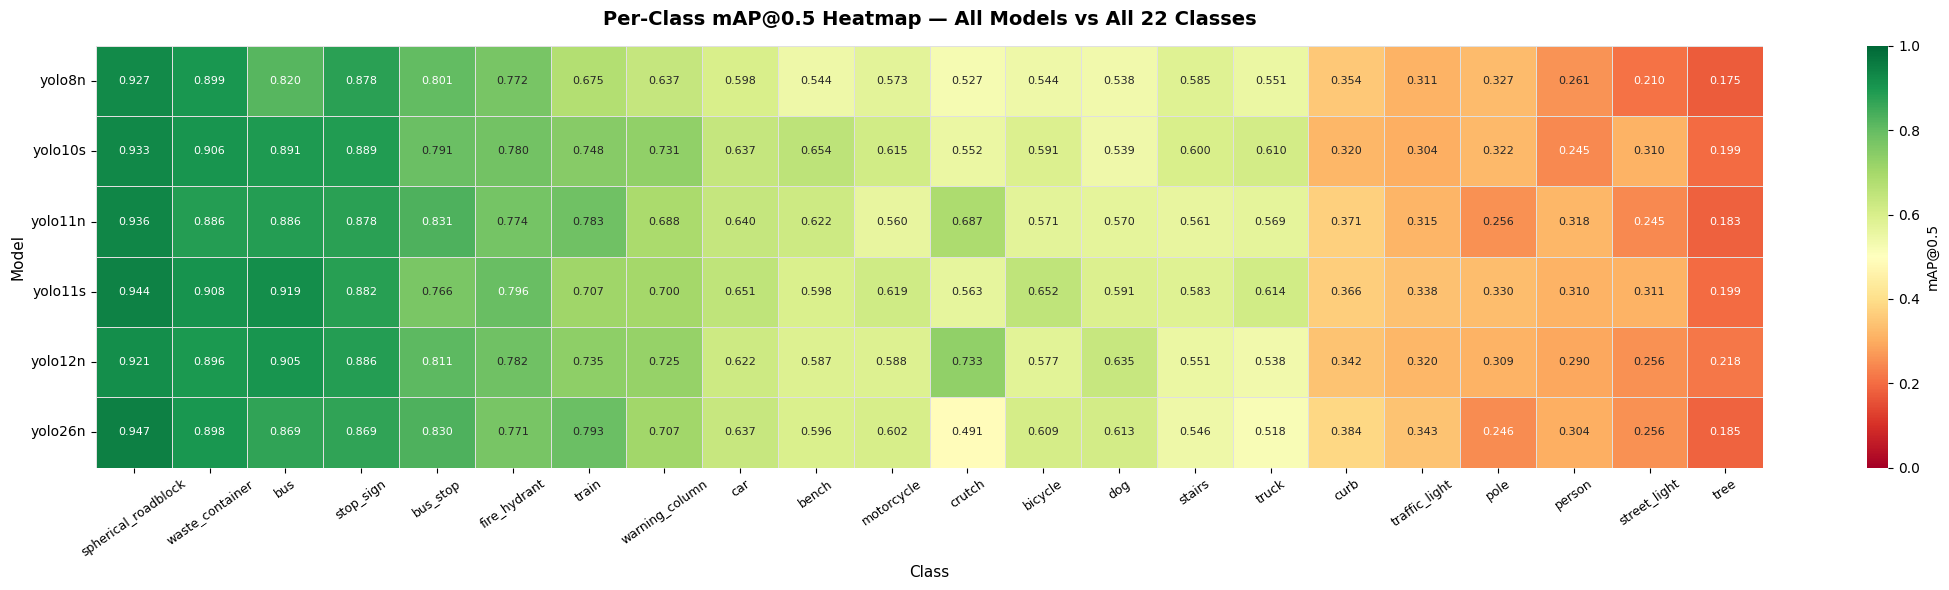


Best model per class:
---------------------------------------------
  spherical_roadblock    -> yolo26n    (0.9468)
  waste_container        -> yolo11s    (0.9082)
  bus                    -> yolo11s    (0.9193)
  stop_sign              -> yolo10s    (0.8895)
  bus_stop               -> yolo11n    (0.8308)
  fire_hydrant           -> yolo11s    (0.7963)
  train                  -> yolo26n    (0.7927)
  warning_column         -> yolo10s    (0.7310)
  car                    -> yolo11s    (0.6507)
  bench                  -> yolo10s    (0.6540)
  motorcycle             -> yolo11s    (0.6192)
  crutch                 -> yolo12n    (0.7325)
  bicycle                -> yolo11s    (0.6518)
  dog                    -> yolo12n    (0.6350)
  stairs                 -> yolo10s    (0.5999)
  truck                  -> yolo11s    (0.6136)
  curb                   -> yolo26n    (0.3837)
  traffic_light          -> yolo26n    (0.3431)
  pole                   -> yolo11s    (0.3303)
  person           

In [1]:
# ═══ PER-CLASS HEATMAP — All 6 Models ═══
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display

df = pd.read_csv("perclass_map50_all_models.csv", index_col="model")
CLASS_NAMES = df.columns.tolist()

# Sort classes by mean mAP across models
class_means = df.mean(axis=0).sort_values(ascending=False)
df = df[class_means.index]

print("Per-Class mAP@0.5 — All Models")
print("=" * 70)
print(df.to_string(float_format="{:.4f}".format))

# Styled table
styled = (
    df.style
    .set_caption("Per-Class mAP@0.5 — All Models (22 classes, val split)")
    .format("{:.4f}")
    .background_gradient(cmap="RdYlGn", axis=None, vmin=0, vmax=1)
    .highlight_max(axis=0, color="#d4edda")
    .set_properties(**{"text-align": "center", "font-size": "12px"})
    .set_table_styles([
        {"selector": "caption", "props": [("font-size","15px"),("font-weight","bold"),("padding","10px")]},
        {"selector": "th",      "props": [("background-color","#1a1a2e"),("color","white"),("font-size","11px"),("padding","7px")]},
        {"selector": "td",      "props": [("padding","5px 10px")]},
    ])
)
display(styled)

# ── Heatmap ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 6))
sns.heatmap(
    df,
    annot=True, fmt=".3f", cmap="RdYlGn",
    vmin=0, vmax=1,
    linewidths=0.5, linecolor="#e0e0e0",
    annot_kws={"size": 8},
    ax=ax,
    cbar_kws={"label": "mAP@0.5"}
)
ax.set_title("Per-Class mAP@0.5 Heatmap — All Models vs All 22 Classes", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Class", fontsize=11)
ax.set_ylabel("Model", fontsize=11)
ax.tick_params(axis="x", rotation=35, labelsize=9)
ax.tick_params(axis="y", rotation=0, labelsize=10)
plt.tight_layout()
plt.savefig("perclass_heatmap_all_models.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary: best model per class ─────────────────────────────────────────
print("\nBest model per class:")
print("-" * 45)
for cls in class_means.index:
    best_model = df[cls].idxmax()
    best_val   = df[cls].max()
    print(f"  {cls:22s} -> {best_model:10s} ({best_val:.4f})")

# ── Weak classes across all models ────────────────────────────────────────
print(f"\nHardest classes (mean mAP < 0.40):")
hard = class_means[class_means < 0.40]
for cls, v in hard.items():
    print(f"  {cls:22s} mean: {v:.4f}")

print("\nEasiest classes (mean mAP > 0.80):")
easy = class_means[class_means > 0.80]
for cls, v in easy.items():
    print(f"  {cls:22s} mean: {v:.4f}")

print(f"\nSaved -> perclass_heatmap_all_models.png")
